In [23]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('customer_churn.csv')

In [4]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [5]:
df.shape

(64374, 12)

In [6]:
df = df.drop(columns = ['CustomerID'])

In [7]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

In [8]:
df.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique().sort_values()

Gender                 2
Churn                  2
Subscription Type      3
Contract Length        3
Support Calls         11
Usage Frequency       30
Last Interaction      30
Payment Delay         31
Age                   48
Tenure                60
Total Spend          901
dtype: int64

In [11]:
corr_matrix =df.corr(numeric_only = 'True')

<Axes: >

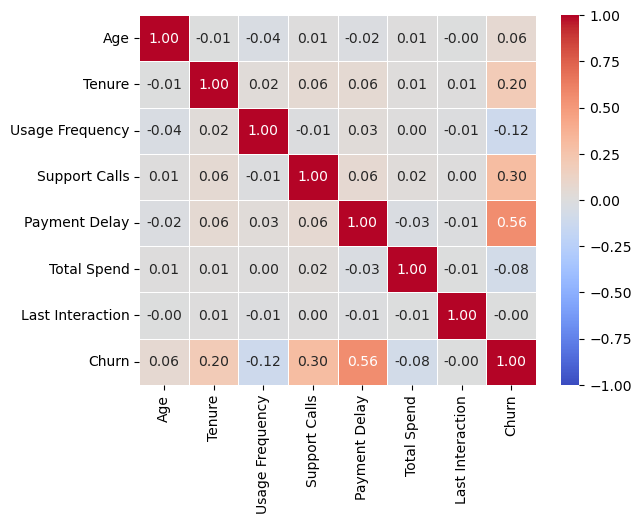

In [12]:
sns.heatmap(corr_matrix,
            annot=True,          # Show the correlation numbers inside the squares
            fmt=".2f",           # Round numbers to 2 decimal places
            cmap="coolwarm",     # Red = strong positive, Blue = strong negative
            vmin=-1, vmax=1,     # Set the scale limits from -1 to 1
            linewidths=0.5)

<Axes: xlabel='Payment Delay', ylabel='Age'>

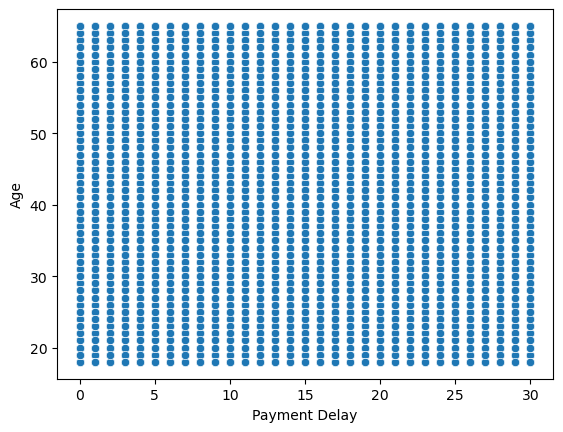

In [13]:
sns.scatterplot(data=df,
               x = 'Payment Delay', y = 'Age')

In [14]:
df['Churn'].value_counts()

Churn
0    33881
1    30493
Name: count, dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                64374 non-null  int64 
 1   Gender             64374 non-null  object
 2   Tenure             64374 non-null  int64 
 3   Usage Frequency    64374 non-null  int64 
 4   Support Calls      64374 non-null  int64 
 5   Payment Delay      64374 non-null  int64 
 6   Subscription Type  64374 non-null  object
 7   Contract Length    64374 non-null  object
 8   Total Spend        64374 non-null  int64 
 9   Last Interaction   64374 non-null  int64 
 10  Churn              64374 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 5.4+ MB


In [16]:
df['Payment Delay'].value_counts()

Payment Delay
22    2821
27    2818
25    2781
26    2781
30    2774
21    2766
29    2748
24    2748
28    2726
23    2716
16    2363
17    2337
18    2284
20    2280
19    2261
10    1646
14    1618
13    1608
0     1594
11    1589
4     1588
12    1587
15    1586
5     1568
8     1559
3     1543
6     1541
7     1539
1     1539
9     1534
2     1531
Name: count, dtype: int64

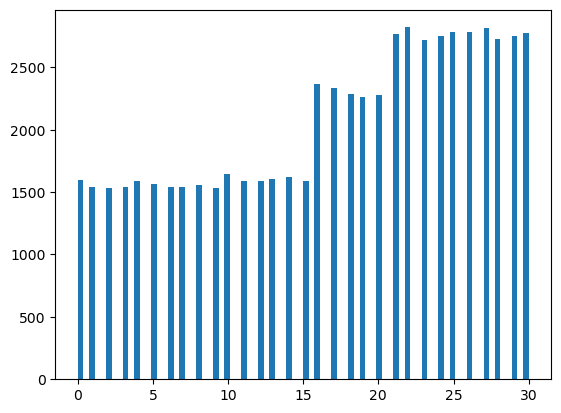

In [17]:
plt.hist(df['Payment Delay'], bins=80);

In [18]:
df['Payment Delay'].max()

30

In [19]:
df.isna().sum()


Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

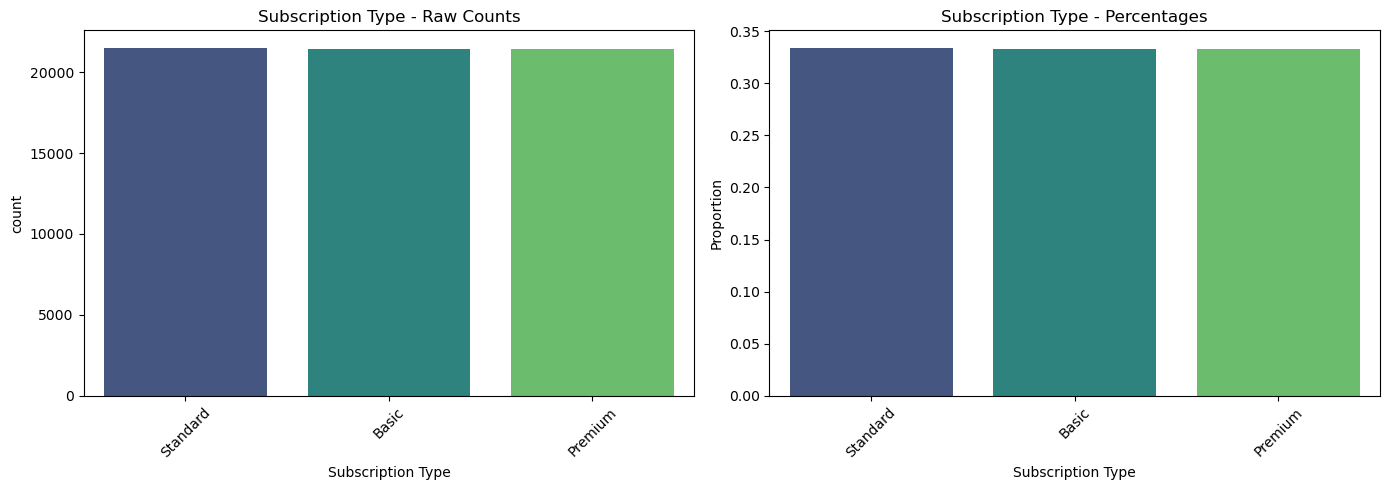

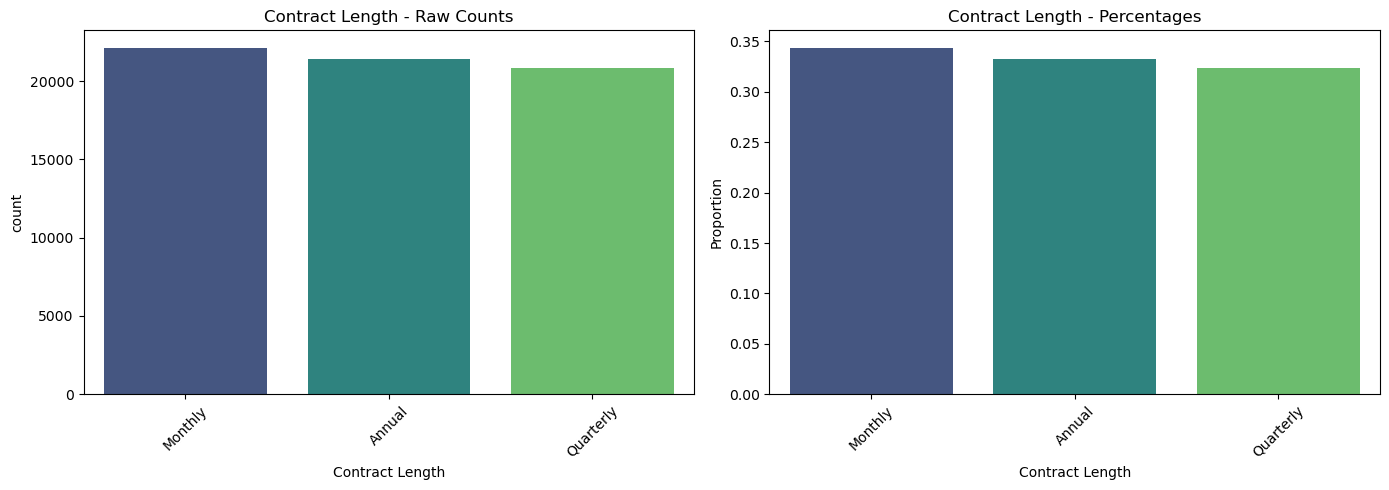

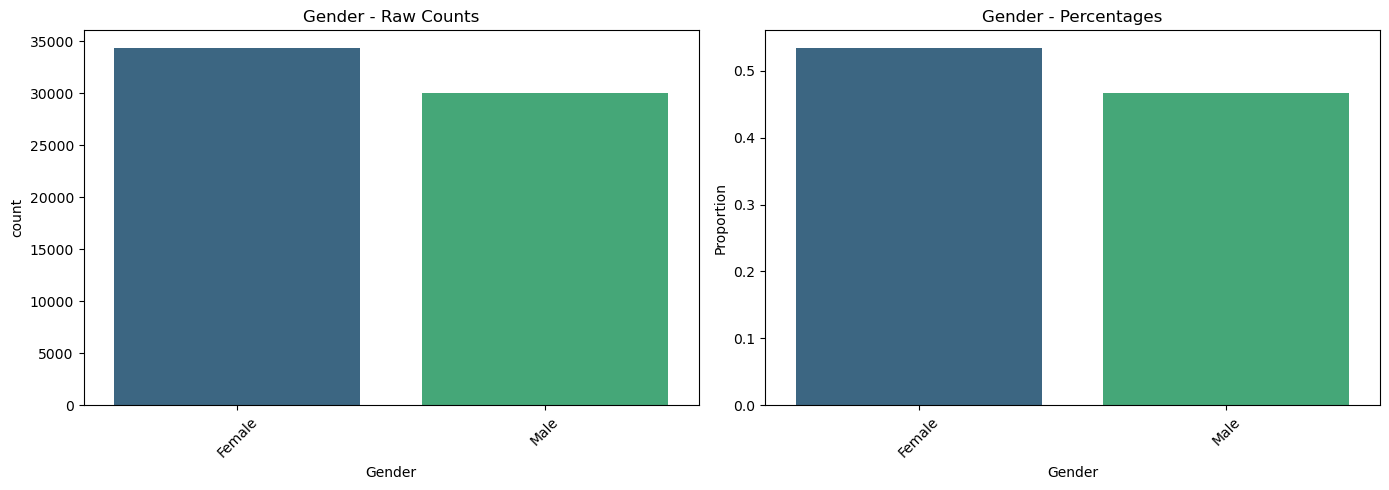

In [24]:
cat_cols = ['Subscription Type', 'Contract Length', 'Gender'] 

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Count Plot
    sns.countplot(data=df, x=col, ax=axes[0], palette='viridis', order=df[col].value_counts().index)
    axes[0].set_title(f'{col} - Raw Counts')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Right: Percentage Plot
    prop_df = df[col].value_counts(normalize=True).reset_index()
    prop_df.columns = [col, 'percentage']
    sns.barplot(data=prop_df, x=col, y='percentage', ax=axes[1], palette='viridis')
    axes[1].set_title(f'{col} - Percentages')
    axes[1].set_ylabel('Proportion')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()